In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [66]:
!python --version

Python 3.12.12


In [67]:
# !pip list - pentru a vedea modulele instalate

# Tensor -> un fel de array

In [68]:
numere = np.array([1,2,3,4])
numere, type(numere)

(array([1, 2, 3, 4]), numpy.ndarray)

In [69]:
tf.constant(numere)

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>

In [70]:
tf.zeros(shape=(3,3))

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

In [71]:
tf.ones(shape=(3,3))

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [72]:
tf.ones(shape=(3,3)) * 4

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[4., 4., 4.],
       [4., 4., 4.],
       [4., 4., 4.]], dtype=float32)>

In [73]:
my_tensor = tf.fill(dims=(3,3), value=4)
my_tensor

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[4, 4, 4],
       [4, 4, 4],
       [4, 4, 4]], dtype=int32)>

In [74]:
my_tensor.numpy()

array([[4, 4, 4],
       [4, 4, 4],
       [4, 4, 4]], dtype=int32)

In [75]:
np.random.randint(low=0, high=10, size=(3,3))

array([[1, 7, 4],
       [1, 8, 5],
       [8, 6, 8]])

In [76]:
tf.random.uniform(minval=0, maxval=10, shape=(3,3))

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[4.576782 , 3.1992972, 7.159128 ],
       [7.1677103, 9.494356 , 6.928114 ],
       [2.7727342, 4.87448  , 7.122822 ]], dtype=float32)>

In [77]:


variabila_tf = tf.Variable([1, 2, 3, 4])
variabila_tf


<tf.Variable 'Variable:0' shape=(4,) dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [78]:
variabila_tf + 10 # creaza o noua variabila

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([11, 12, 13, 14], dtype=int32)>

In [79]:
variabila_tf

<tf.Variable 'Variable:0' shape=(4,) dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [80]:
variabila_tf.assign_add([10, 10, 10, 10])

<tf.Variable 'UnreadVariable' shape=(4,) dtype=int32, numpy=array([11, 12, 13, 14], dtype=int32)>

# Schimbare in place vs new_var

In [81]:
variabila_tf

<tf.Variable 'Variable:0' shape=(4,) dtype=int32, numpy=array([11, 12, 13, 14], dtype=int32)>

# Se poate schimba tipul executie  din menu (Executie -> schimbati tipul executiei)

In [82]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [83]:
with tf.device('/device:CPU:0'):
  print("Acum se executa pe CPU")

Acum se executa pe CPU


In [84]:
with tf.device('/device:GPU:0'):
  print("Acum se executa pe GPU")

Acum se executa pe GPU


# Cum putem construi un model in tensorflow

In [85]:
from sklearn.linear_model import LinearRegression

In [86]:
model = LinearRegression()
model

LinearRegression()

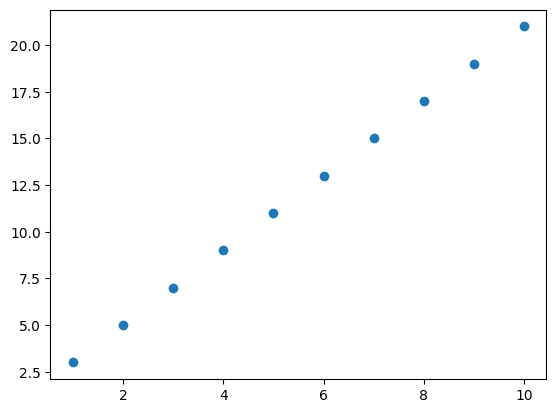

In [87]:
x = np.arange(1, 11)
y = 2 * x + 1

plt.scatter(x, y)

In [98]:
x = x.reshape(-1, 1)
x

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [99]:
model.fit(x, y)


LinearRegression()

In [90]:
model.coef_, model.intercept_

(array([2.]), np.float64(0.9999999999999982))

# Keras -> este un wrapper peste Tensorflow

In [91]:
tf.keras

<module 'keras._tf_keras.keras' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/__init__.py'>

In [92]:
import keras

In [93]:
keras

<module 'keras' from '/usr/local/lib/python3.12/dist-packages/keras/__init__.py'>

In [113]:
model_sequential = tf.keras.models.Sequential()
model_sequential

<Sequential name=sequential_3, built=False>

In [100]:
x[0].shape

(1,)

In [114]:
input_layer = tf.keras.layers.Input(shape=(1,))
input_layer

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>

In [115]:
model_sequential.add(input_layer)
model_sequential

<Sequential name=sequential_3, built=False>

In [104]:
model_sequential.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [116]:
first_dense_layer = tf.keras.layers.Dense(units=1)
model_sequential.add(first_dense_layer)
model_sequential

<Sequential name=sequential_3, built=True>

In [106]:
model_sequential.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

# Modelul secvential trebuie compilat

In [117]:
model_sequential.compile(optimizer='adam', loss="mean_squared_error", metrics=["mae"])

In [118]:
EPOCHS = 20
model_sequential.fit(x, y, epochs=EPOCHS)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - loss: 357.5706 - mae: 16.9708
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 357.3022 - mae: 16.9643
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 357.0338 - mae: 16.9578
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 356.7655 - mae: 16.9513
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 356.4973 - mae: 16.9448
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 356.2293 - mae: 16.9383
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 355.9614 - mae: 16.9318
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 355.6935 - mae: 16.9253
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 355.4258 - mae: 16.9188
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 355.1582 - mae: 16.9123
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 354.8907 - mae: 16.9058
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 354.6233 - mae: 16.8993
Epoch 13/20
1/1 ━━━━━━━━

In [122]:
df = pd.DataFrame(model_sequential.history.history)
df


,loss,mae
0,357.570618,16.970778
1,357.302155,16.964275
2,357.033783,16.957777
3,356.765503,16.951275
4,356.497345,16.944777
5,356.229279,16.938278
6,355.961365,16.931778
7,355.693512,16.925282
8,355.425812,16.918781
9,355.158203,16.912283


In [119]:
model_sequential.predict(np.array([[2]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


array([[-1.7475823]], dtype=float32)